# ___Power Analysis___
---------------------------

In [1]:
!python --version

Python 3.14.2


The system cannot find the path specified.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
from numba import njit

ImportError: Numba needs NumPy 2.3 or less. Got NumPy 2.4.

## ___Example___
----------------------

In [1]:
clinic = pd.read_csv(r"./clinical_trial.csv")

NameError: name 'pd' is not defined

In [6]:
# continuous variable - mood_gain
# two grouping variables - drug & therapy
clinic

,drug,therapy,mood_gain
0,placebo,no.therapy,0.5
1,placebo,no.therapy,0.3
2,placebo,no.therapy,0.1
3,anxifree,no.therapy,0.6
4,anxifree,no.therapy,0.4
5,anxifree,no.therapy,0.2
6,joyzepam,no.therapy,1.4
7,joyzepam,no.therapy,1.7
8,joyzepam,no.therapy,1.3
9,placebo,CBT,0.6


In [8]:
# for now, let's just look at the effect of drug on mood gain
clinic.loc[:, ["drug", "mood_gain"]]

,drug,mood_gain
0,placebo,0.5
1,placebo,0.3
2,placebo,0.1
3,anxifree,0.6
4,anxifree,0.4
5,anxifree,0.2
6,joyzepam,1.4
7,joyzepam,1.7
8,joyzepam,1.3
9,placebo,0.6


In [13]:
# every group has three participants
clinic.groupby(["drug", "therapy"]).count()

mood_gain
drug     therapy              
anxifree CBT                 3
         no.therapy          3
joyzepam CBT                 3
         no.therapy          3
placebo  CBT                 3
         no.therapy          3

In [11]:
clinic.loc[:, ["drug", "mood_gain"]].groupby("drug", as_index=False).agg(["mean", "std"])

drug mood_gain          
                 mean       std
0  anxifree  0.716667  0.392003
1  joyzepam  1.483333  0.213698
2   placebo  0.450000  0.281069

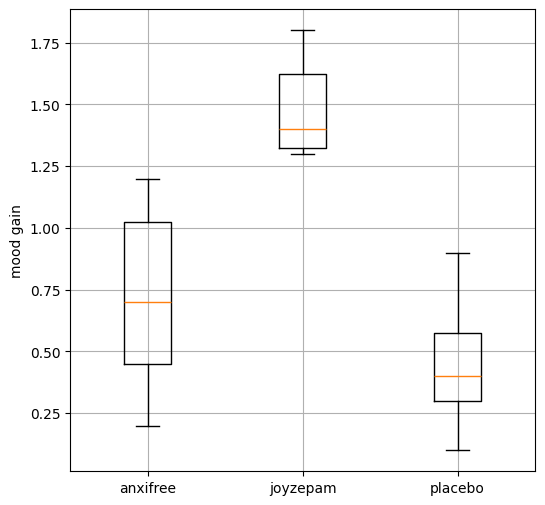

In [21]:
fig, axes = plt.subplots()
fig.set_size_inches(6, 6)
axes.boxplot(x=[df.mood_gain for (_, df) in clinic.loc[:, ["drug", "mood_gain"]].groupby("drug", as_index=False)])
axes.set_xticklabels([d for (d, _) in clinic.loc[:, ["drug", "mood_gain"]].groupby("drug", as_index=False)])
axes.set_ylabel("mood gain")
axes.grid()
plt.show()

## ___Hypotheses___
---------------------

In [ ]:
# chapter 3 hypotheses

# Sympatric host ecotype – AM fungal community pairs will demonstrate superior adaptive fitness 
# (measured by total plant biomass, plant height, PRLC & total length of hyphae in gram soil) compared to their allopatric counterparts

# The extent of outsourcing reflected in the fine absorptive root traits will be the highest for each plant ecotype when paired with 
# sympatric AM fungal community compared to pairings with foreign AM fungal communities.

# Amongst the sympatric AM fungal-host ecotype pairs, the magnitude of this influence will be more pronounced where the hosts needed the
# AM fungi more (e.g. low phosphorus soils).

# The fine absorptive root traits (collaboration gradient) will also be influenced by the AM fungal community composition in the soil
# samples, but this influence will be less pronounced compared to the provenance specific coadaptations.

In [2]:
# first what statistical test will be best to analyze our data???

# hypo 1 - two sample t test
# hypo 2 - same, two sample t test

# BUT OUR GROUPS ARE NOT INDEPENDENT - 

# hypo 3 - linear regression??
# hypo 4 - a factorial ANOVA?? - two grouping variables => sympatry/allopatry and mycorrhizal community composition